# Question 2 — Classification
Using Decision Trees to classify whether a song would be liked by Sriharsha or Janya.

A song is considered liked if the user has played it 2 or more times(most balanced split)

In [31]:
import os
os.chdir('/Users/muadshaikh/Spotify-Wrapped')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')

## 1. Load Data

In [ ]:
def load_user(folder):
    records = []
    for i in range(5):
        try:
            records += json.load(open(f'public/{folder}/StreamingHistory_music_{i}.json', encoding='utf-8'))
        except FileNotFoundError:
            break
    df = pd.DataFrame(records)
    df = df[df['msPlayed'] >= 5000].copy()
    df['minutes'] = df['msPlayed'] / 60000
    df['track_key'] = df['trackName'] + ' | ' + df['artistName']
    df['endTime'] = pd.to_datetime(df['endTime'], utc=True).dt.tz_convert('America/Chicago')
    df['hour'] = df['endTime'].dt.hour
    df['dow'] = df['endTime'].dt.dayofweek
    df['month'] = df['endTime'].dt.month
    df['date'] = df['endTime'].dt.date
    return df

sri = load_user('s')
jan = load_user('j')
track_info = json.load(open('public/track_info.json', encoding='utf-8'))

ALL_FEATURES = ['energy', 'danceability', 'happiness', 'acousticness',
                'instrumentalness', 'liveness', 'speechiness', 'tempo', 'popularity',
                'loudness_db', 'duration_sec', 'mode', 'key']

# --- Tune these thresholds based on user input ---
SRI_LIKED_THRESHOLD = 2   
JAN_LIKED_THRESHOLD = 2   

print(f'Sriharsha: {len(sri):,} plays | Janya: {len(jan):,} plays')
print(f'Track info cache: {len(track_info):,} tracks')
print(f'Thresholds — Sri: {SRI_LIKED_THRESHOLD} plays | Janya: {JAN_LIKED_THRESHOLD} plays')

Sriharsha: 10,422 plays | Janya: 14,153 plays
Track info cache: 6,591 tracks
Thresholds — Sri: 2 plays | Janya: 2 plays


## 2. Build Labeled Dataset

In [33]:
def build_dataset(df, liked_threshold):
    rows = []
    for track_key, group in df.groupby('track_key'):
        info = track_info.get(track_key)
        if info:
            base_feats = ['energy','danceability','happiness','acousticness',
                         'instrumentalness','liveness','speechiness','tempo','popularity']
            feat = {f: info.get(f) for f in base_feats}
            if all(v is not None for v in feat.values()):
                # loudness: strip ' dB' and convert to float
                loudness = info.get('loudness')
                if loudness is None: continue
                try: feat['loudness_db'] = float(str(loudness).replace(' dB',''))
                except: continue
                # duration: convert 'M:SS' to seconds
                duration = info.get('duration')
                if duration is None: continue
                try:
                    parts = str(duration).split(':')
                    feat['duration_sec'] = int(parts[0])*60 + int(parts[1])
                except: continue
                # mode: major=1, minor=0
                mode = info.get('mode')
                if mode is None: continue
                feat['mode'] = 1 if str(mode).lower() == 'major' else 0
                # key: convert to numeric
                key_map = {'C':0,'C#':1,'Db':1,'D':2,'D#':3,'Eb':3,'E':4,'F':5,
                           'F#':6,'Gb':6,'G':7,'G#':8,'Ab':8,'A':9,'A#':10,'Bb':10,'B':11}
                key = info.get('key')
                if key is None: continue
                feat['key'] = key_map.get(str(key), -1)
                if feat['key'] == -1: continue
                feat['liked'] = int(len(group) >= liked_threshold)
                rows.append(feat)
    return pd.DataFrame(rows)

sri_df = build_dataset(sri, SRI_LIKED_THRESHOLD)
jan_df = build_dataset(jan, JAN_LIKED_THRESHOLD)

print(f'Sri  — total: {len(sri_df):,} | liked: {sri_df["liked"].sum():,} ({100*sri_df["liked"].mean():.1f}%)')
print(f'Janya — total: {len(jan_df):,} | liked: {jan_df["liked"].sum():,} ({100*jan_df["liked"].mean():.1f}%)')

Sri  — total: 2,889 | liked: 1,407 (48.7%)
Janya — total: 3,243 | liked: 1,301 (40.1%)


## Builing Labeled Dataset

For each unique track in a user's streaming history, we are pulling audio features from track_info.json. These features include energy, sensibility, happiness, acousticness, instrumentalness, liveness speaking, this tempo, popularity, loudness, duration, mode, and key. All of these features are then fed as input into the decision tree(X), And play count(Y) determines Whether a song is liked by the user or not. If the song is played two or more times than it is liked and if not then otherwise. We chose Too specifically. Because it yielded the most evenly split data set with Sriharsha Obtaining a 49% to 51% Data split while With Jania, you were able to obtain a 40% to 60% data split. 


## 3. Train Decision Trees

=== Sriharsha ===
Train accuracy: 0.5980 | Test accuracy: 0.5536
              precision    recall  f1-score   support

   Not Liked       0.58      0.48      0.53       297
       Liked       0.53      0.63      0.58       281

    accuracy                           0.55       578
   macro avg       0.56      0.56      0.55       578
weighted avg       0.56      0.55      0.55       578



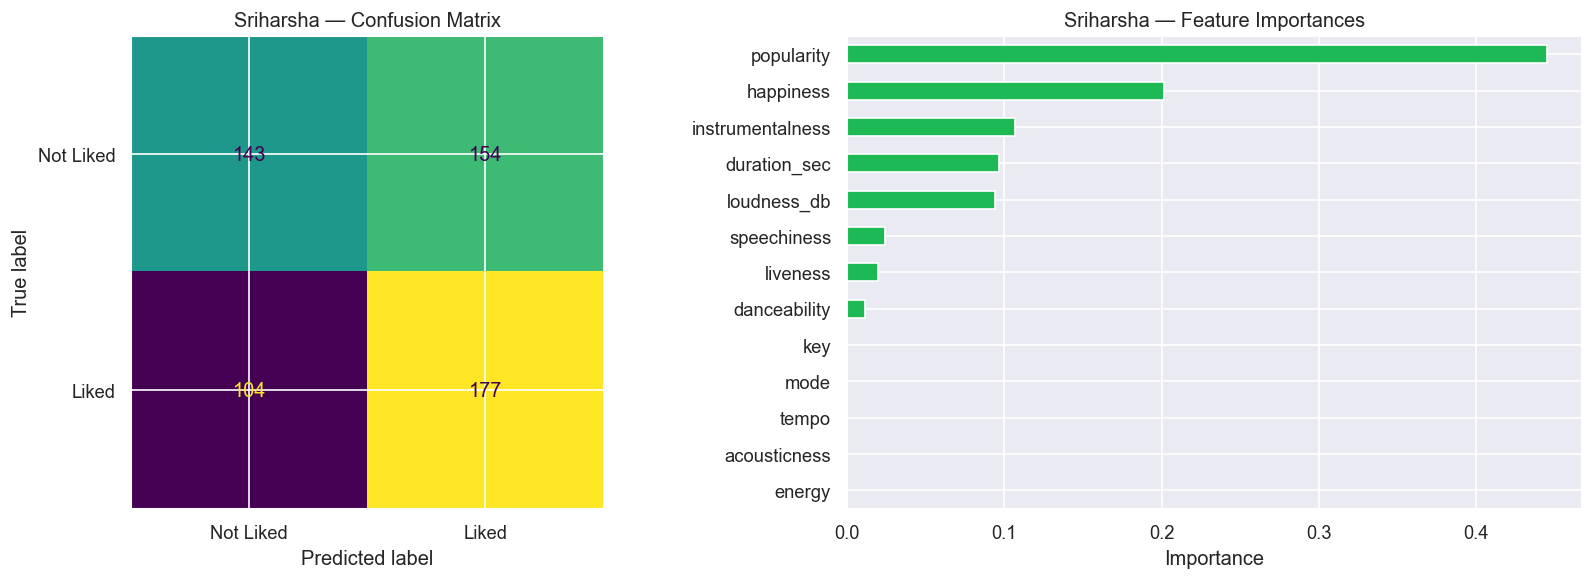

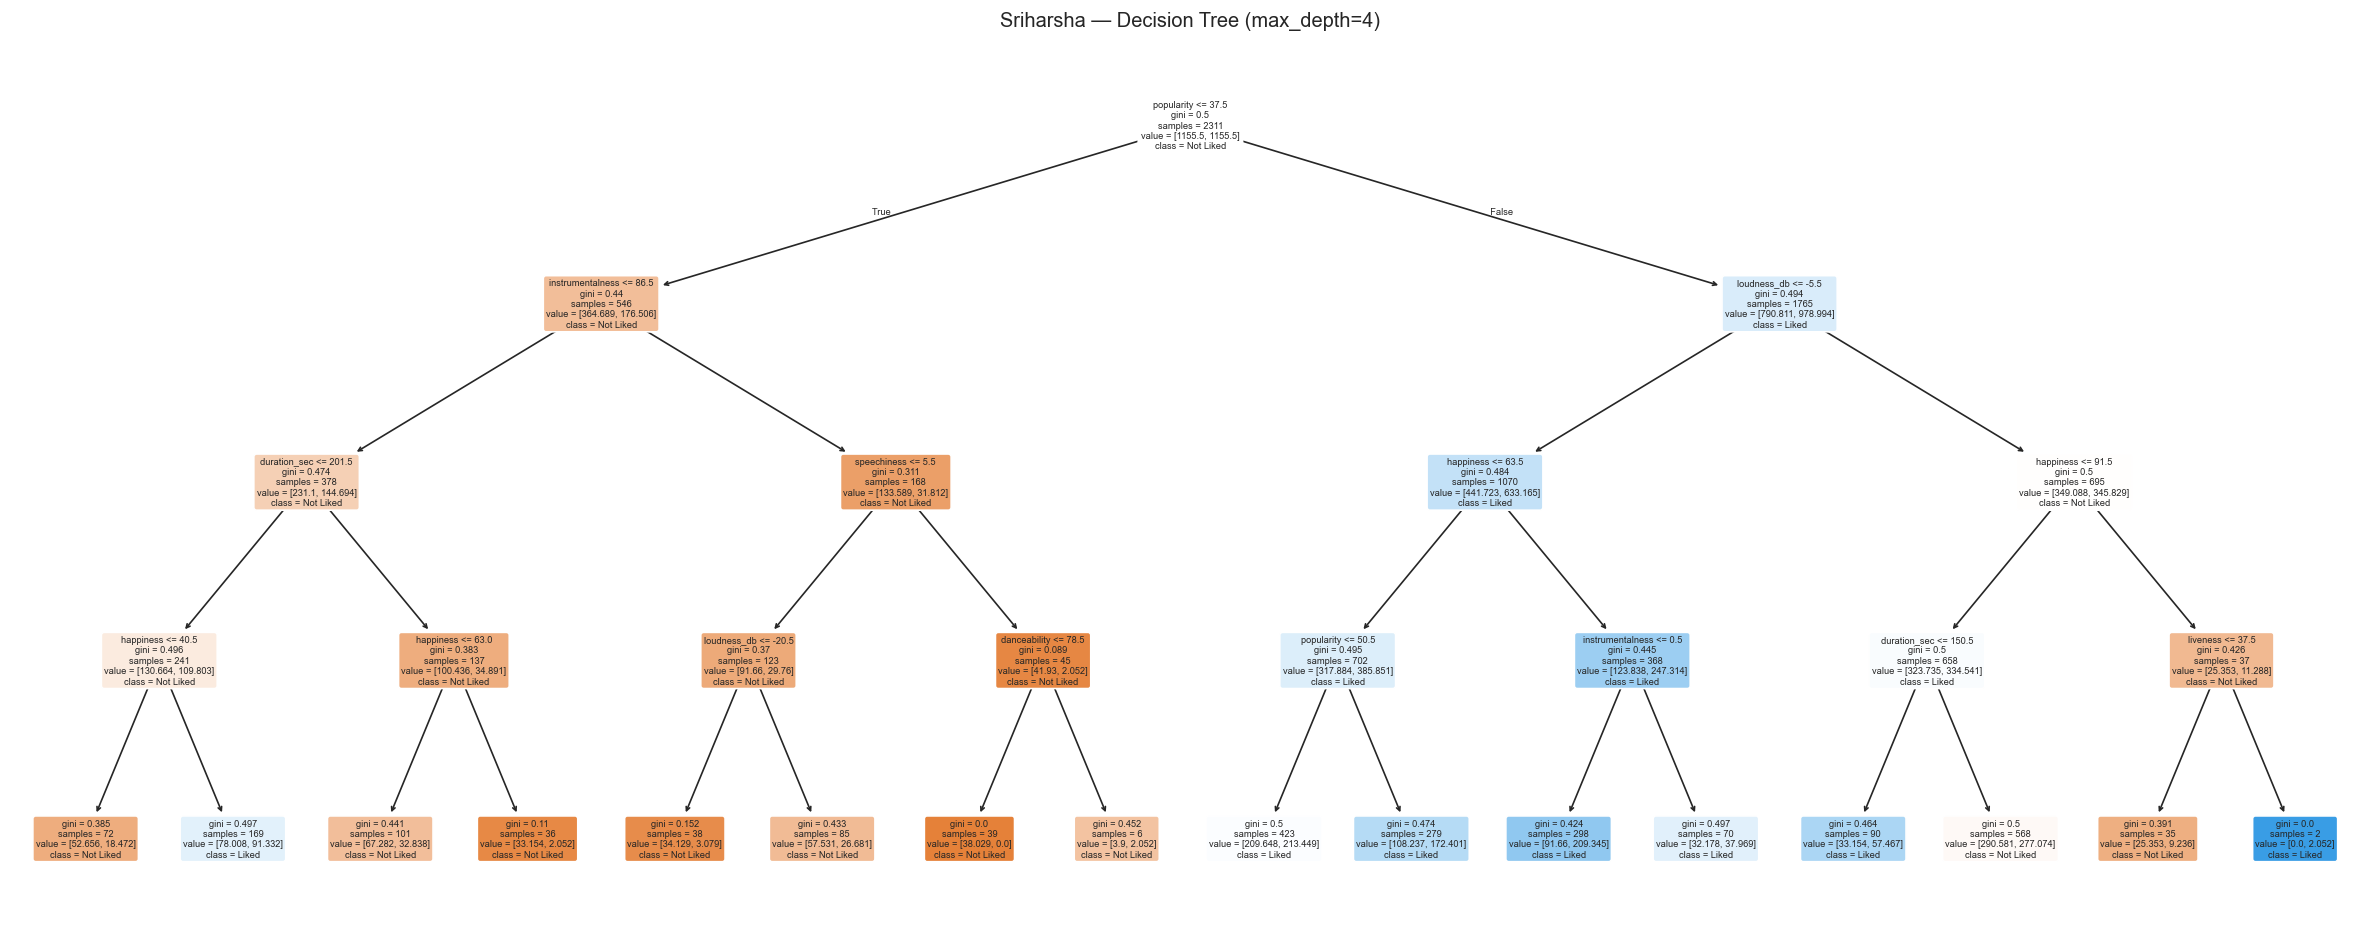

=== Janya ===
Train accuracy: 0.5891 | Test accuracy: 0.5270
              precision    recall  f1-score   support

   Not Liked       0.63      0.52      0.57       389
       Liked       0.43      0.54      0.48       260

    accuracy                           0.53       649
   macro avg       0.53      0.53      0.52       649
weighted avg       0.55      0.53      0.53       649



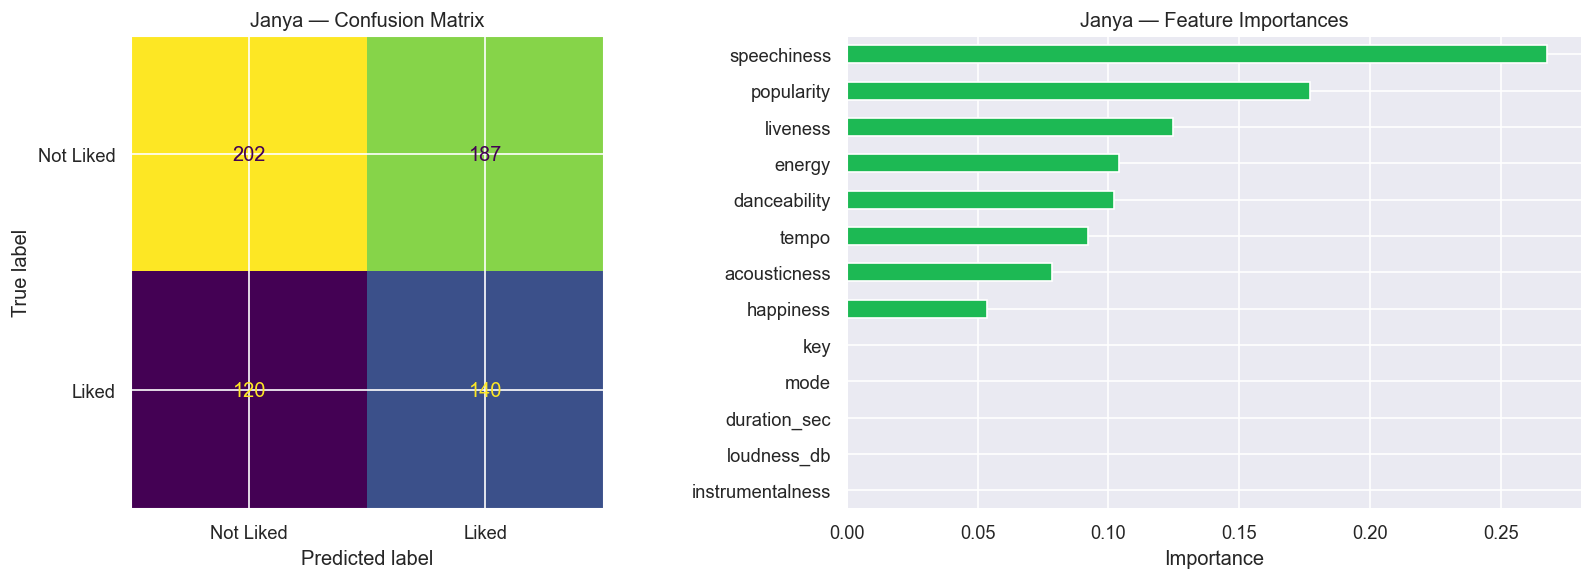

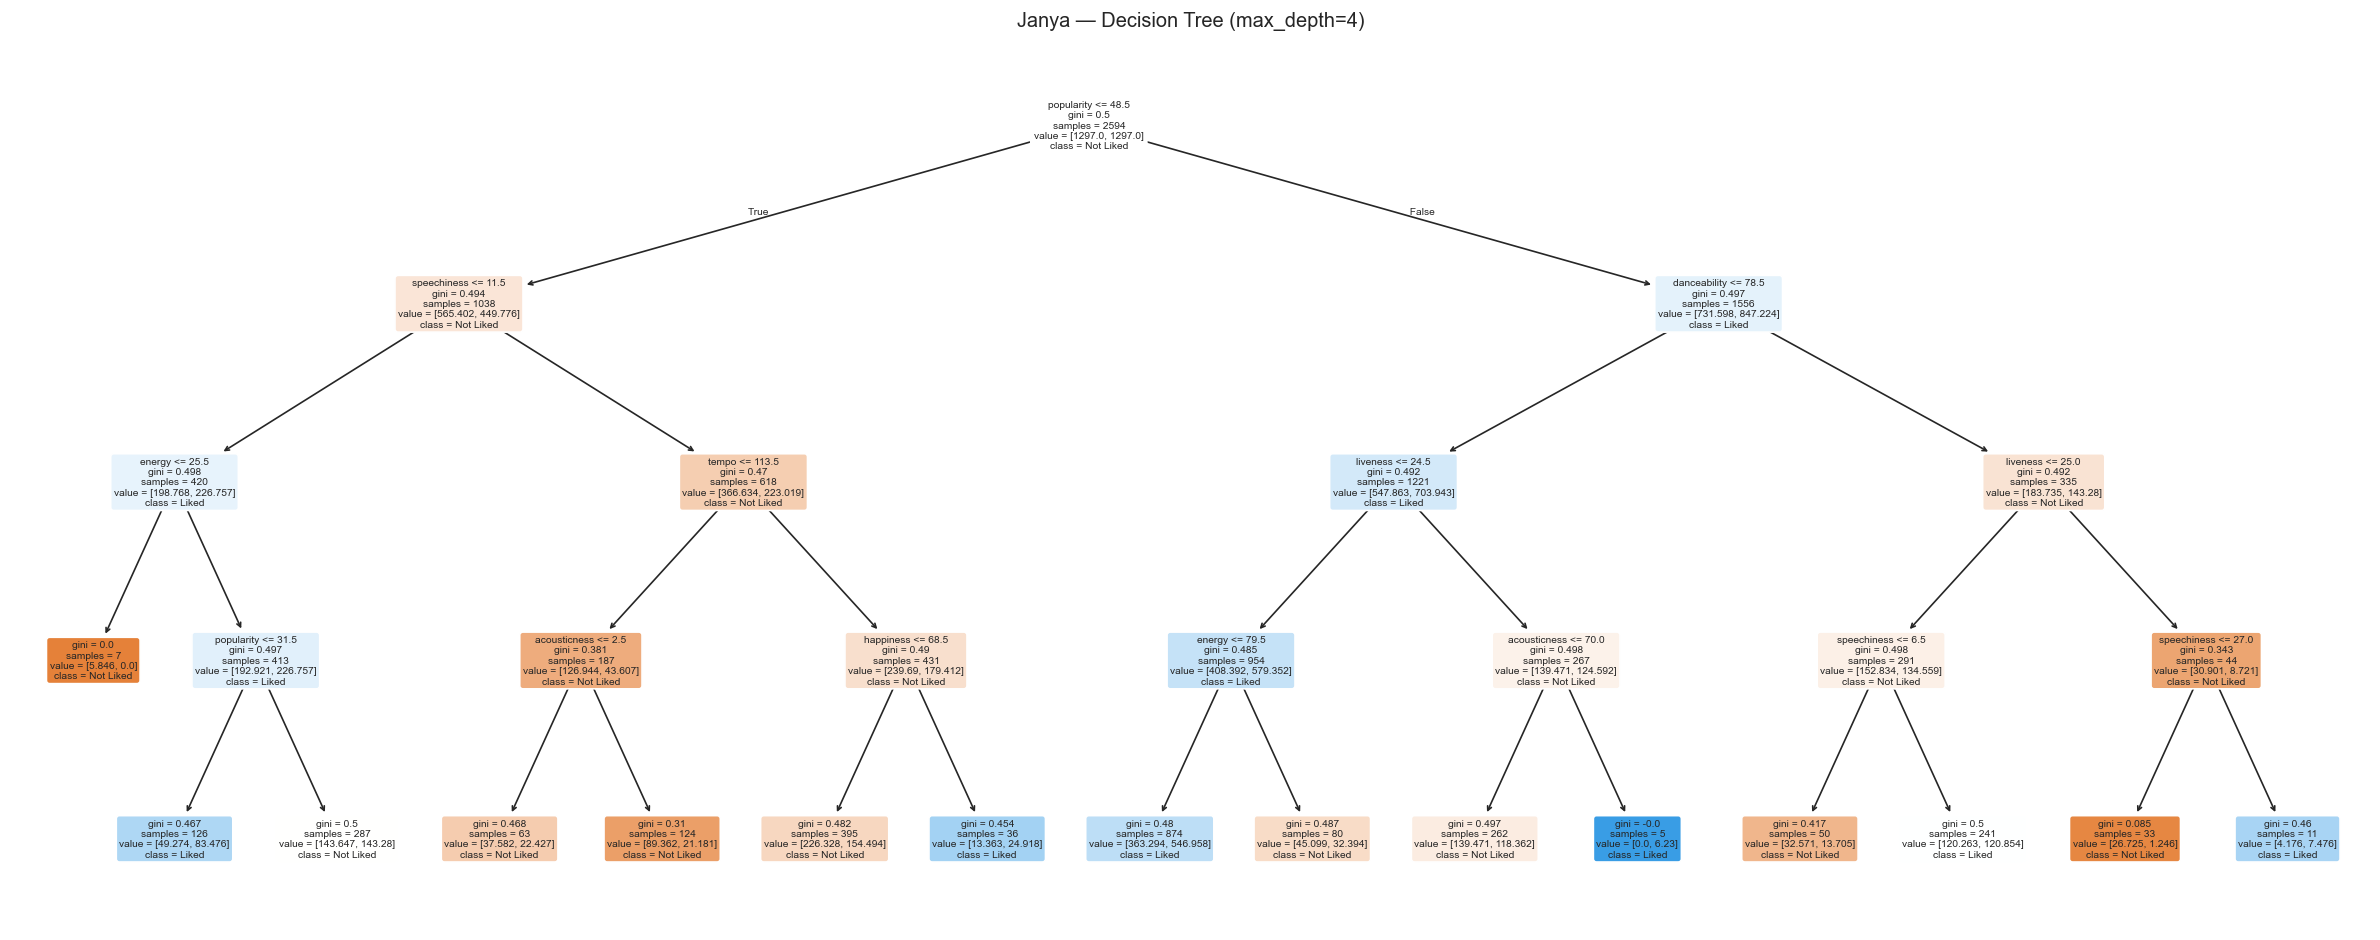

In [34]:
def train_tree(df, name):
    X = df[ALL_FEATURES]
    y = df['liked']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    clf = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    train_acc = clf.score(X_train, y_train)
    test_acc  = clf.score(X_test, y_test)
    print(f'=== {name} ===')
    print(f'Train accuracy: {train_acc:.4f} | Test accuracy: {test_acc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Not Liked', 'Liked']))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['Not Liked', 'Liked']).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f'{name} — Confusion Matrix')

    importances = pd.Series(clf.feature_importances_, index=ALL_FEATURES).sort_values(ascending=True)
    importances.plot(kind='barh', ax=axes[1], color='#1DB954')
    axes[1].set_title(f'{name} — Feature Importances')
    axes[1].set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(20, 8))
    plot_tree(clf, feature_names=ALL_FEATURES, class_names=['Not Liked', 'Liked'],
              filled=True, rounded=True, ax=ax)
    plt.title(f'{name} — Decision Tree (max_depth=4)')
    plt.tight_layout()
    plt.show()

    return clf

sri_clf = train_tree(sri_df, 'Sriharsha')
jan_clf = train_tree(jan_df, 'Janya')

As stated before, the decision trees above were trained specifically on mapping feature data to likeability for the two users, with Sriharshas DT acheiving an accuracy of 56% and Janya's acheiving an accuracy of 53%. Variables like minutes_played or times a song was played were used to define whether a song was "liked" or not. 

Sriharsha's tree has its first split on populairty <= 37.5. The left and right tree created off of popularity alone have leaf nodes that cleanly classify songs as either liked or disliked, indicating that popularity is the single greatest indicator of whether Sri prefers a song. Happiness and instrumentalness are also large secondary indicators of whether Sri would prefer a song or not. Other audio features like mode, tempo, and energy do not contribute anything to the overall decision. 

Sri's confusion matrix shows that the model has high recall for predicting liked, at 63%, but low precision at 48%. This indicates that when the model is unsure of a song, it often predicts liked instead of liked. Practically, if Sri were to use this model for recommendations, he would find songs he actually liked but with a large amount of noise.

Janya's tree also has her first split on popularity <= 48.5, but unlike Sri, this is not the deciding factor for whether Janya would like a song or not. As observed in her decision tree, after the first split, child nodes are not cleanly split into distinct classes after splitting on popularity. In fact, the feature importance graph shows that speechiness is the largest indicator of whether Janya would prefer a song or not. This is followed by popularity, liveness, energy, and dacneacbility. Similar to Sri, loudness, key, and mode had no significant contribution to song preference. 

Janya's confusion matrix also shows that the model has a problem with clearly identifying not liked songs and misclassifies 187 of them as liked. Calculated precison is 43% and recall is 54%, indicating that the model cannot infer with just these attributes what music Janya tends towards. This is reflected in her feature importance chart, where no single feature dominates for importannce. 